# CommPy quickstart

[CommPy](https://github.com/MarvinElling/CommPy) is a general-purpose Python library for communications engineering: channel coding, digital modulation, OFDM, information theory, queuing theory, and link-level simulation, built on NumPy/SciPy.

This notebook runs three self-contained demos:
1. Digital modulation through an AWGN channel, with a constellation plot.
2. A Monte-Carlo BER waterfall simulation.
3. A full transmit/receive chain: source coding, channel coding, modulation, a multipath channel, equalization, and decoding — recovering the original text exactly.

More examples live in [`examples/`](https://github.com/MarvinElling/CommPy/tree/main/examples), and the full docs are at [marvinelling.github.io/CommPy](https://marvinelling.github.io/CommPy/).

In [1]:
try:
    import commpy  # noqa: F401
except ImportError:
    %pip install -q commpy

## 1. Modulation + AWGN: constellation

16-QAM symbols sent through an AWGN channel — the scatter plot shows the received symbols clustering around the ideal, Gray-coded constellation points.

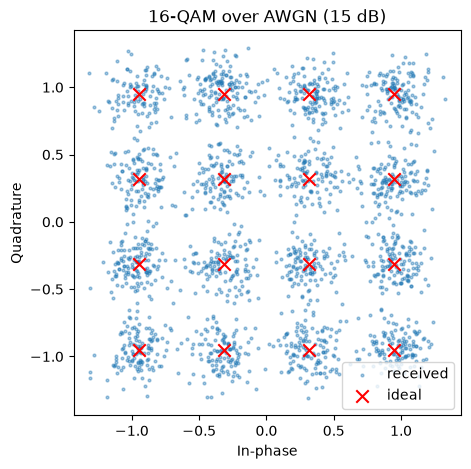

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from commpy import Channels, MQAMModulator

rng = np.random.default_rng(0)
mod = MQAMModulator(16)

bits = rng.integers(0, 2, mod.bits_per_symbol * 2000)
symbols = mod.modulate(bits)
received = Channels.awgn(symbols, snr_db=15, rng=rng)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(received.real, received.imag, s=4, alpha=0.4, label='received')
ax.scatter(
    mod.constellation.real, mod.constellation.imag,
    c='red', marker='x', s=80, label='ideal',
)
ax.set_title('16-QAM over AWGN (15 dB)')
ax.set_xlabel('In-phase')
ax.set_ylabel('Quadrature')
ax.axis('equal')
ax.legend()
plt.show()

## 2. Monte-Carlo BER waterfall

`simulate_ber` runs an early-stopping Monte-Carlo sweep (with Wilson-score confidence intervals) across a range of SNRs, and `plot_waterfall` plots the result against a theoretical reference curve.

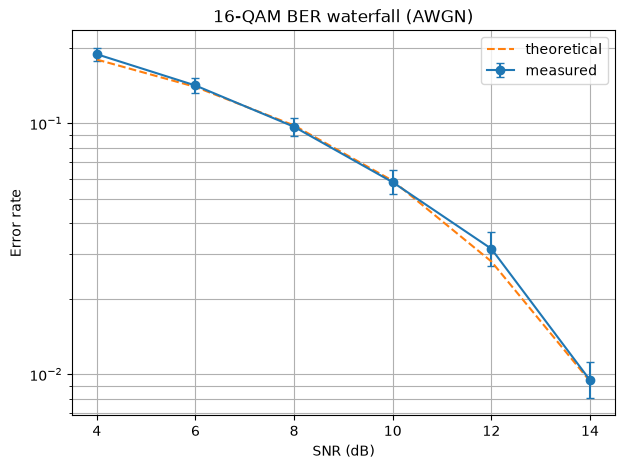

In [3]:
from scipy.special import erfc

from commpy import plot_waterfall, simulate_ber

snr_db_range = [4.0, 6.0, 8.0, 10.0, 12.0, 14.0]
result = simulate_ber(
    mod, Channels.awgn, snr_db_range,
    bits_per_batch=5_000, target_errors=100, max_trials=2_000_000, rng=rng,
)


def theoretical_qam_ber(snr_db: np.ndarray, m: int, k: int) -> np.ndarray:
    """Standard approximate square-QAM BER formula (Gray-coded, high-SNR)."""
    snr_lin = 10**(np.asarray(snr_db) / 10)
    ber = (4 / k) * (1 - 1 / np.sqrt(m)) * 0.5 * erfc(np.sqrt(3 * snr_lin / (2 * (m - 1))))
    return np.asarray(ber)


ax = plot_waterfall(
    result, theoretical=lambda snr: theoretical_qam_ber(snr, mod.M, mod.bits_per_symbol),
)
ax.set_title('16-QAM BER waterfall (AWGN)')
plt.show()

## 3. Full TX/RX chain

Composing most of CommPy's pieces end to end:

```
text --Huffman--> compressed bits --convolutional code--> coded bits
     --BPSK modulate--> symbols --multipath channel + AWGN-->
     --ZF equalize--> --soft demodulate (LLRs)--> --Viterbi decode-->
coded bits --Huffman decode--> text
```

This is the classic layered picture: source coding removes redundancy, channel coding adds structured redundancy back for error protection (the separation theorem), and the physical layer (modulation, channel, equalization) sits in between.

In [4]:
from collections import Counter

from commpy import (
    ConvolutionalEncoder,
    MPSKModulator,
    Trellis,
    huffman_codes,
    huffman_decode,
    huffman_encode,
    viterbi_decode,
    zf_equalizer,
)

text = 'the quick brown fox jumps over the lazy dog ' * 4
channel_taps = np.array([1.0, 0.3, -0.15])  # a short multipath channel
equalizer_taps = 21
snr_db = 8.0
chain_rng = np.random.default_rng(0)

# 1. Source coding: Huffman-compress the text.
counts = Counter(text)
total = sum(counts.values())
probabilities = {ch: n / total for ch, n in counts.items()}
codes = huffman_codes(probabilities)
compressed = huffman_encode(list(text), codes)
source_bits = np.array([int(b) for b in compressed])
print(f'1. Huffman: {len(text) * 8} bits -> {len(source_bits)} bits')

# 2. Channel coding: rate-1/2 convolutional code, zero-tail terminated.
trellis = Trellis(constraint_length=7, generators=(0o171, 0o133))
encoder = ConvolutionalEncoder(trellis)
codeword, _ = encoder.encode(source_bits, terminate=True)
print(f'2. Convolutional code: {len(source_bits)} bits -> {len(codeword)} coded bits')

# 3. Modulation: BPSK.
bpsk = MPSKModulator(2)
tx_symbols = bpsk.modulate(codeword)

# 4. Channel: multipath (ISI) + AWGN.
tx = np.convolve(tx_symbols, channel_taps)
rx = Channels.awgn(tx, snr_db, rng=chain_rng)
print(f'4. Multipath channel ({len(channel_taps)} taps) + AWGN at {snr_db} dB SNR')

# 5. Equalization: zero-forcing FIR equalizer removes the ISI.
equalizer = zf_equalizer(channel_taps, equalizer_taps)
equalized = np.convolve(rx, equalizer)
delay = (len(channel_taps) + equalizer_taps - 1) // 2
recovered_symbols = equalized[delay:delay + len(tx_symbols)]

# 6-7. Soft demodulation (LLRs) + soft-decision Viterbi decoding.
llrs = bpsk.soft_demodulate(recovered_symbols, noise_var=1.0)
decoded_bits = viterbi_decode(trellis, llrs, mode='soft', terminated=True)
bit_errors = int(np.sum(decoded_bits != source_bits))
print(f'6-7. Equalize + soft-demod + Viterbi-decode: {bit_errors}/{len(source_bits)} bit errors')

# 8. Source decoding: Huffman-decompress back to text.
recovered_text = ''.join(huffman_decode(''.join(str(b) for b in decoded_bits), codes))
print(f'8. Huffman decode: {"OK, exact match" if recovered_text == text else "MISMATCH"}')

assert bit_errors == 0
assert recovered_text == text
print('\nFull chain OK: original text recovered exactly after the full TX/RX pipeline.')

1. Huffman: 1408 bits -> 776 bits
2. Convolutional code: 776 bits -> 1564 coded bits
4. Multipath channel (3 taps) + AWGN at 8.0 dB SNR


6-7. Equalize + soft-demod + Viterbi-decode: 0/776 bit errors
8. Huffman decode: OK, exact match

Full chain OK: original text recovered exactly after the full TX/RX pipeline.


## Next steps

- [`docs/GETTING_STARTED.md`](https://github.com/MarvinElling/CommPy/blob/main/docs/GETTING_STARTED.md) — a tutorial per major feature area.
- [`docs/API.md`](https://github.com/MarvinElling/CommPy/blob/main/docs/API.md) — full API reference.
- [`examples/`](https://github.com/MarvinElling/CommPy/tree/main/examples) — more runnable scripts (Reed-Solomon, OFDM, SigMF I/O, ...).